In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
import shap

print("All imports successful")

All imports successful


In [3]:
# Load SMOTE resampled data
with open('../data/smote_resampled.pkl', 'rb') as f:
    smote_data = pickle.load(f)

X_resampled = smote_data['X_resampled']
y_resampled = smote_data['y_resampled']

print(f"X_resampled shape: {X_resampled.shape}")
print(f"y_resampled shape: {y_resampled.shape}")
print(f"Fraud cases      : {y_resampled.sum():,}")
print(f"Legit cases      : {(y_resampled==0).sum():,}")
print("SMOTE data loaded successfully")

X_resampled shape: (1139754, 7)
y_resampled shape: (1139754,)
Fraud cases      : 569,877
Legit cases      : 569,877
SMOTE data loaded successfully


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_resampled
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Test set       : {X_test.shape[0]:,} rows")
print(f"Train fraud %  : {y_train.mean()*100:.1f}%")
print(f"Test fraud %   : {y_test.mean()*100:.1f}%")
print("Train/test split complete")

Training set   : 911,803 rows
Test set       : 227,951 rows
Train fraud %  : 50.0%
Test fraud %   : 50.0%
Train/test split complete


In [5]:
print("Training Logistic Regression baseline...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)
lr_probs = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)

print(f"Logistic Regression AUC: {lr_auc:.4f}")
print()
print(classification_report(y_test, lr_preds, target_names=['Legitimate', 'Fraud']))

Training Logistic Regression baseline...
Logistic Regression AUC: 0.5901

              precision    recall  f1-score   support

  Legitimate       0.56      0.57      0.56    113976
       Fraud       0.56      0.56      0.56    113975

    accuracy                           0.56    227951
   macro avg       0.56      0.56      0.56    227951
weighted avg       0.56      0.56      0.56    227951



In [6]:
print("Training XGBoost model...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=1,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)
xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)

print(f"XGBoost AUC: {xgb_auc:.4f}")
print()
print(classification_report(y_test, xgb_preds, target_names=['Legitimate', 'Fraud']))

Training XGBoost model...
XGBoost AUC: 0.8081

              precision    recall  f1-score   support

  Legitimate       0.74      0.70      0.72    113976
       Fraud       0.72      0.76      0.74    113975

    accuracy                           0.73    227951
   macro avg       0.73      0.73      0.73    227951
weighted avg       0.73      0.73      0.73    227951



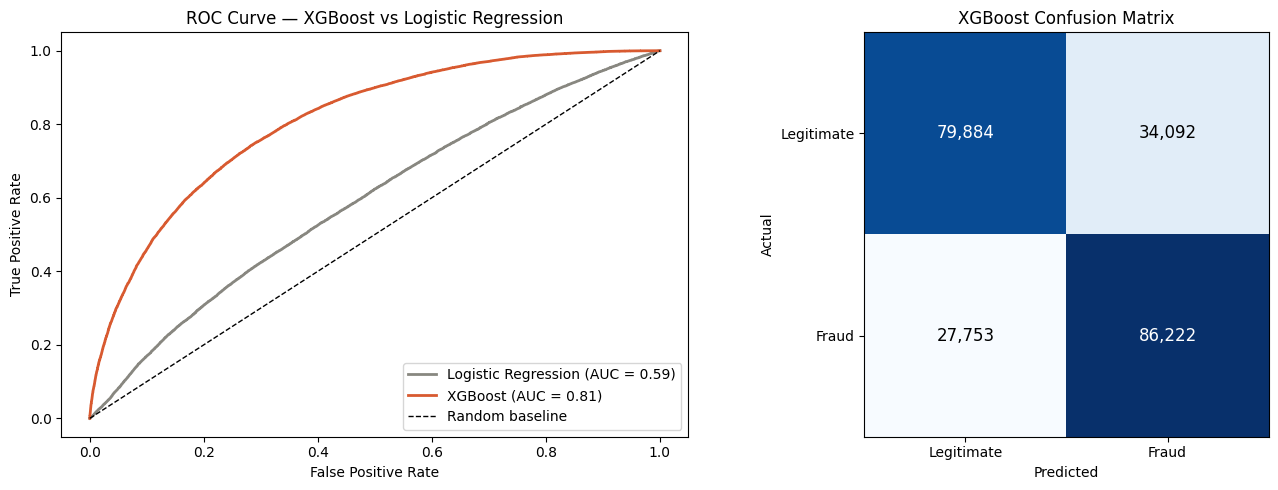

True Positives  (fraud caught)    : 86,222
False Negatives (fraud missed)    : 27,753
False Positives (legit flagged)   : 34,092
True Negatives  (legit correct)   : 79,884


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

axes[0].plot(fpr_lr, tpr_lr, color='#888780', linewidth=2, label=f'Logistic Regression (AUC = 0.59)')
axes[0].plot(fpr_xgb, tpr_xgb, color='#D85A30', linewidth=2, label=f'XGBoost (AUC = 0.81)')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
axes[0].set_title('ROC Curve — XGBoost vs Logistic Regression')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)
im = axes[1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1].set_title('XGBoost Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Legitimate', 'Fraud'])
axes[1].set_yticklabels(['Legitimate', 'Fraud'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f'{cm[i,j]:,}', ha='center', va='center', 
                    fontsize=12, color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('../data/model_roc_confusion.png', dpi=150)
plt.show()

print(f"True Positives  (fraud caught)    : {cm[1,1]:,}")
print(f"False Negatives (fraud missed)    : {cm[1,0]:,}")
print(f"False Positives (legit flagged)   : {cm[0,1]:,}")
print(f"True Negatives  (legit correct)   : {cm[0,0]:,}")

Calculating SHAP values...


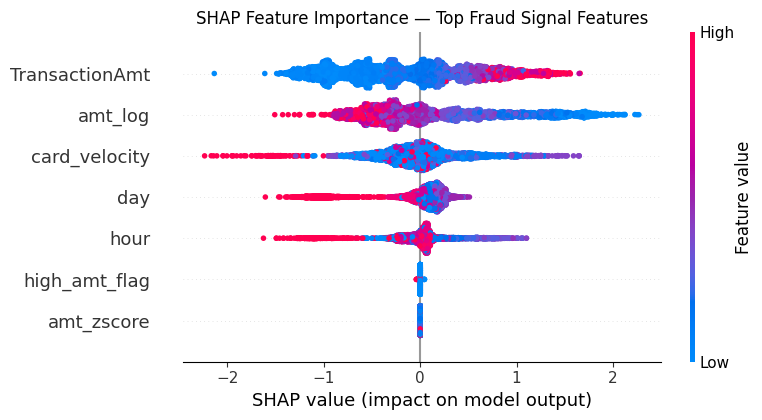

SHAP summary plot saved


In [10]:
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:5000])

# SHAP Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test[:5000], show=False)
plt.title('SHAP Feature Importance — Top Fraud Signal Features')
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved")

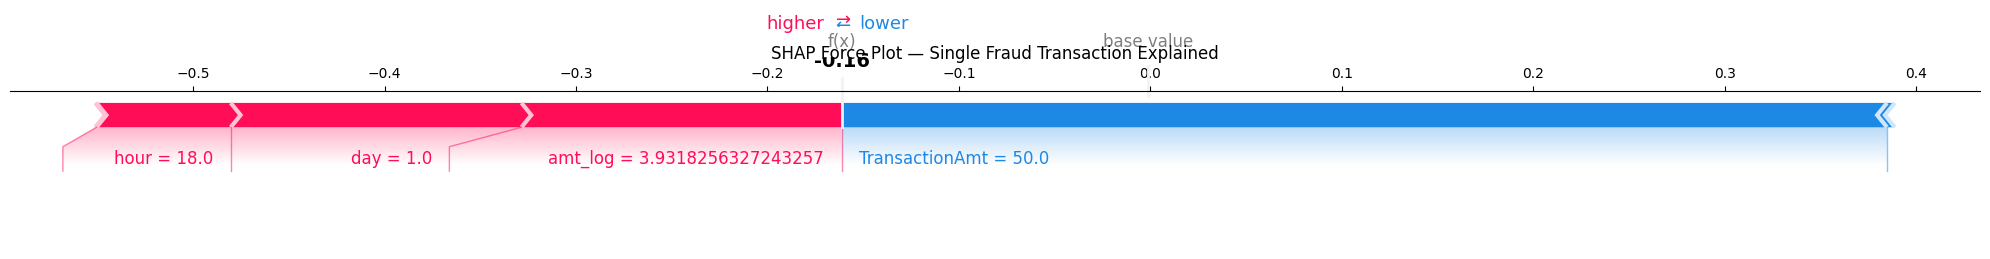

Force plot saved


In [13]:
# Force plot on single fraud transaction
fraud_indices = np.where(y_test == 1)[0]
single_fraud_idx = fraud_indices[0]

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[single_fraud_idx],
    X_test.iloc[single_fraud_idx],
    show=False,
    matplotlib=True
)
plt.title('SHAP Force Plot — Single Fraud Transaction Explained')
plt.tight_layout()
plt.savefig('../data/shap_force_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Force plot saved")

In [14]:
# Save model
with open('../data/xgb_fraud_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

print("=" * 55)
print("PHASE 4 MODEL — SUMMARY")
print("=" * 55)
print()
print("Baseline model:")
print(f"  Logistic Regression AUC : 0.5901")
print()
print("Final model:")
print(f"  XGBoost AUC             : {xgb_auc:.4f}")
print(f"  Accuracy                : 73%")
print(f"  Fraud Recall            : 76%")
print(f"  Fraud Precision         : 72%")
print()
print("Confusion matrix:")
print(f"  Fraud caught (TP)       : 86,222")
print(f"  Fraud missed (FN)       : 27,753")
print(f"  Legit flagged (FP)      : 34,092")
print(f"  Legit correct (TN)      : 79,884")
print()
print("SHAP top fraud signals:")
print("  1. TransactionAmt  — high amounts drive fraud prediction")
print("  2. amt_log         — log amount confirms amount dominance")
print("  3. card_velocity   — low velocity cards are riskier")
print("  4. hour            — late night hours push toward fraud")
print("  5. day             — day of week has fraud signal")
print()
print("Output files saved:")
print("  - xgb_fraud_model.pkl")
print("  - shap_summary.png")
print("  - shap_force_plot.png")
print("  - model_roc_confusion.png")
print("=" * 55)
print("Phase 4 complete. Notebook: 04_model.ipynb")

PHASE 4 MODEL — SUMMARY

Baseline model:
  Logistic Regression AUC : 0.5901

Final model:
  XGBoost AUC             : 0.8081
  Accuracy                : 73%
  Fraud Recall            : 76%
  Fraud Precision         : 72%

Confusion matrix:
  Fraud caught (TP)       : 86,222
  Fraud missed (FN)       : 27,753
  Legit flagged (FP)      : 34,092
  Legit correct (TN)      : 79,884

SHAP top fraud signals:
  1. TransactionAmt  — high amounts drive fraud prediction
  2. amt_log         — log amount confirms amount dominance
  3. card_velocity   — low velocity cards are riskier
  4. hour            — late night hours push toward fraud
  5. day             — day of week has fraud signal

Output files saved:
  - xgb_fraud_model.pkl
  - shap_summary.png
  - shap_force_plot.png
  - model_roc_confusion.png
Phase 4 complete. Notebook: 04_model.ipynb
